In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/project_1/customer_reviews_cleaned.csv')

In [3]:
df['review_date'] = pd.to_datetime(df['review_date'])

In [4]:
import re

def clean_review(text):
    if pd.isna(text):
        return text

    # Fix 'wordbr nextword' → 'word. next word'
    text = re.sub(r'(\w)br\s+', r'\1. ', text)

    # Remove any remaining standalone 'br'
    text = re.sub(r'\bbr\b', '', text)

    # Fix multiple spaces
    text = re.sub(r' {2,}', ' ', text)

    return text.strip()

df['review_body_clean'] = df['review_body_clean'].apply(clean_review)
df['review_headline_clean'] = df['review_headline_clean'].apply(clean_review)

In [5]:
#Creating Sentiment Labels
def sentiment_label(rating):
    if rating >= 4:
        return "Positive"
    elif rating == 3:
        return "Neutral"
    else:
        return "Negative"

df["sentiment_label"] = df["star_rating"].apply(sentiment_label)

#Complaint Category Frequency Table

In [13]:
# Negative reviews only
negative_df = df[df['sentiment_label'] == 'Negative'].copy()

complaint_dict = {
    'Device Performance Issues': ['slow','freeze','lag','crash','stuck','performance','device	'],
    'App Issues': ['app','apps','download','install','software'],
    'Screen Issues': ['screen','display','touchscreen','resolution'],
    'Battery Issues': ['battery','charge','charging','power'],
    'Delivery Issues': ['delivery','shipping','arrived','late'],
    'Packaging Issues': ['package','packaging','box'],
    'Durability Issues': ['broken','damage','damaged','durable','cracked'],
    'Price Issues': ['price','expensive','cost','worth']
}

In [14]:
def categorize_review(text):
    text = str(text).lower()

    for category, keywords in complaint_dict.items():
        if any(word in text for word in keywords):
            return category

    return 'Other Complaints'

negative_df['Complaint_Category'] = negative_df['review_body_clean'].apply(categorize_review)

In [15]:
complaint_summary = (
    negative_df['Complaint_Category']
    .value_counts()
    .reset_index()
)

complaint_summary.columns = ['Complaint Category','Frequency']

print(complaint_summary)

          Complaint Category  Frequency
0                 App Issues       1054
1           Other Complaints        970
2  Device Performance Issues        326
3             Battery Issues        238
4              Screen Issues        139
5            Delivery Issues         54
6               Price Issues         52
7           Packaging Issues         16
8          Durability Issues         12


#Complaint Distribution Visualization

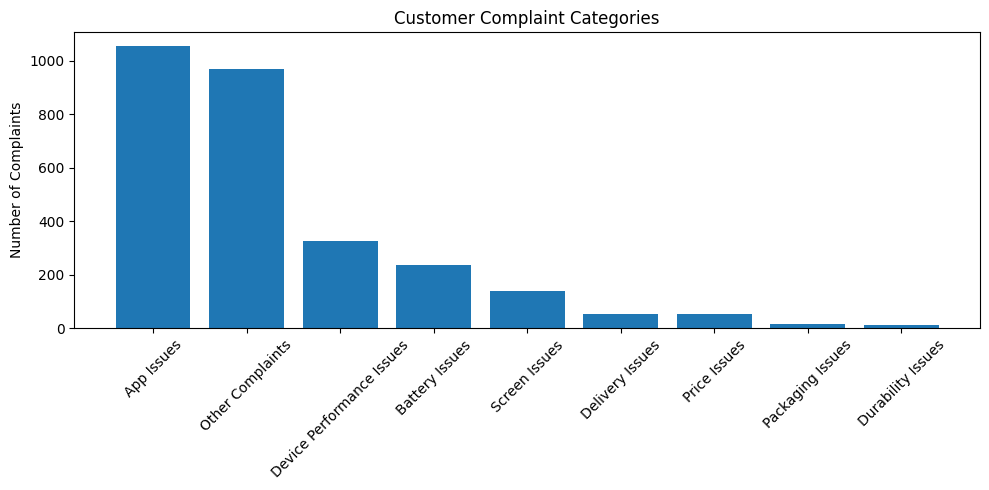

In [16]:
import matplotlib.pyplot as plt

complaint_summary = complaint_summary.sort_values(
    by='Frequency',
    ascending=False
)

plt.figure(figsize=(10,5))

plt.bar(
    complaint_summary['Complaint Category'],
    complaint_summary['Frequency']
)

plt.xticks(rotation=45)
plt.title('Customer Complaint Categories')
plt.ylabel('Number of Complaints')
plt.tight_layout()
plt.show()

#Complaint Percentage Analysis

In [17]:
total_negative = len(negative_df)

complaint_summary['Complaint %'] = round(
    complaint_summary['Frequency'] /
    total_negative * 100,
    2
)

complaint_summary

,Complaint Category,Frequency,Complaint %
0,App Issues,1054,36.84
1,Other Complaints,970,33.90
2,Device Performance Issues,326,11.39
3,Battery Issues,238,8.32
4,Screen Issues,139,4.86
5,Delivery Issues,54,1.89
6,Price Issues,52,1.82
7,Packaging Issues,16,0.56
8,Durability Issues,12,0.42


Analysis of negative customer reviews shows that **App Issues** are the most common complaint category, accounting for **1,054 complaints (36.84%)** of all negative reviews. This indicates that customers frequently experience problems related to app performance, installation, downloads, or software functionality. The second largest category is Other Complaints with 970 reviews (33.90%), suggesting that additional text analysis may be needed to identify more specific recurring issues. Device Performance Issues represent 326 complaints (11.39%), followed by Battery Issues with 238 complaints (8.32%) and Screen Issues with 139 complaints (4.86%). Delivery, Price, Packaging, and Durability Issues together account for less than 5% of total complaints, indicating that product logistics and physical quality are generally not major concerns.

Based on these findings, the company should prioritize improving app stability, software performance, and device functionality, as these categories account for over 56% of all negative feedback. Addressing these issues could significantly reduce customer dissatisfaction, improve product ratings, and enhance the overall customer experience.